### What is Cache-Augmented Generation (CAG)?

CAG is a retrieval-free approach that bypasses the usual step of querying external knowledge source at inference time. Instead, it preloads relevant documents into the LLM's extended context window, precomputes the model's key-value (KV) cache and reuses this during inference - so the model can generate responses without additional retrieval steps

In [1]:
# ------------------------------------------------------------
# 1. Config
# ------------------------------------------------------------

LLM_MODEL = 'openai/gpt-oss-120b'
LLM_TEMP = 0

EMBEDDING_MODEL = 'nomic-embed-text'

RETRIEVE_TOP_K = 4
CACHE_TOP_K = 3

CACHE_DISTANCE_THRESHOLD = 0.45

# Optional TTL for cache entries (seconds) 0 = disabled
CACHE_TTL_SEC = 0

In [ ]:
# ------------------------------------------------------------
# 2. Text Loader - Vector Store
# ------------------------------------------------------------

from langchain_groq import ChatGroq
from langchain_ollama.embeddings import OllamaEmbeddings
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')

# LLM and Embedding
llm = ChatGroq(model=LLM_MODEL, temperature=LLM_TEMP)
embedding = OllamaEmbeddings(model=EMBEDDING_MODEL)

In [3]:
# ------------------------------------------------------------
# 3. STATE
# ------------------------------------------------------------

from typing import TypedDict, List, Optional
from langchain_classic.schema import Document

class RAGState(TypedDict):
    question: str
    normalized_question: str = ''
    context_docs: List[Document] = []
    answer: Optional[str] = []
    citations: List[str] = []
    cache_hit: bool

In [8]:
# ------------------------------------------------------------
# 4. QA CACHE (Empty, Safe Init)
# ------------------------------------------------------------

import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore

# Vector Store
vector_store = FAISS.from_texts(
    texts = [
        'LangGraph lets you compose stateful LLM workflows as graph.',
        'In LangGraph, nodes can be cached; node caching memorizes outputs keyed by inputs for a TL.',
        'Retrieval-Augmented Generation (RAG) retrieves external context and injects it into prompts.',
        'Semantic caching reuses prior answers when new questions are semantically similar.'
    ], 
    embedding=embedding
)

# derive dimension from actual embedding model
VECTOR_DIM = len(embedding.embed_query("test"))

qa_index =  faiss.IndexFlatL2(VECTOR_DIM) # Distance; lower is better
QA_CACHE = FAISS(
    embedding_function=embedding,
    index=qa_index,
    docstore=InMemoryDocstore({}),
    index_to_docstore_id={}
)

print("Embedding dim:", len(embedding.embed_query("hello")))
print("FAISS dim:", QA_CACHE.index.d)

Embedding dim: 768
FAISS dim: 768


In [12]:
# ------------------------------------------------------------
# 5. Nodes
# ------------------------------------------------------------

import time

# Normalize Query
def normalize_query(state: RAGState) -> RAGState:
    question = (state['question'] or '').strip()
    state['normalized_question'] = question.lower()
    return state

# Semantic Cache Lookup
def semantic_cache_lookup(state: RAGState) -> RAGState:
    normalize_question = state['normalized_question']
    state['cache_hit'] = False # Default
    
    if not normalize_question:
        return state
    
    # ✅ Guard: FAISS crashes if ntotal == 0 and you ask for k > 0
    if getattr(QA_CACHE, 'index', None) is None or QA_CACHE.index.ntotal == 0:
        return state
    
    # For FAISS L2 wrapper, this reasons (Document, distance) with lower = better
    hits = QA_CACHE.similarity_search_with_score(normalize_question, k=CACHE_TOP_K)
    
    if not hits:
        return state
    
    best_doc, dist = hits[0]
    
    # Optional TTL
    if CACHE_TTL_SEC > 0:
        ts = best_doc.metadata.get('ts')
        if ts is None or (time.time() - float(ts)) > CACHE_TTL_SEC:
            return state
        
    # L2 distance gate (lower = more similar)
    if dist <= CACHE_DISTANCE_THRESHOLD:
        cached_answer = best_doc.metadata.get('answer')
        if cached_answer:
            state['answer'] = cached_answer
            state['citations'] = ['(cache)']
            state['cache_hit'] = True
            
    return state

# Respond from cache
def respond_from_cache(state: RAGState) -> RAGState:
    return state

# Retrieve
def retrieve(state: RAGState) -> RAGState:
    normalize_question = state['normalized_question']
    docs = vector_store.similarity_search(normalize_question, k=RETRIEVE_TOP_K)
    state['context_docs'] = docs
    return state

# Generate
def generate(state: RAGState) -> RAGState:
    question = state['question']
    docs = state.get('context_docs', [])
    ctx = '\n\n'.join([f'[doc-{i}] {doc.page_content}' for i, doc in enumerate(docs, start=1)])
    
    system = (
        'You are a precise RAG assistant. Use the context when helpful. '
        'Cite with [doc-i] markers if you use a fact from the context.'
    )
    
    user = f'Question: {question} \n\nContext:\n{ctx}\n\nWrite a concise answer with citations.'
    
    response = llm.invoke([
        {'role': 'system', 'content': system},
        {'role': 'user', 'content': user}
    ])
    
    state['answer'] = response.content
    state['citations'] = [f'[doc-{i}]' for i in range(1, len(docs)+1)]
    return state

# Add to Cache - Answer generated
def add_to_cache(state: RAGState) -> RAGState:
    normalize_question = state['normalized_question']
    generated_answer = state.get('answer')
    
    if not normalize_question or not generated_answer:
        return state
    
    QA_CACHE.add_texts(
        texts=[normalize_question],
        metadatas=[
            {
                'answer': generated_answer,
                'ts': time.time()
            }
        ]
    )
    return state

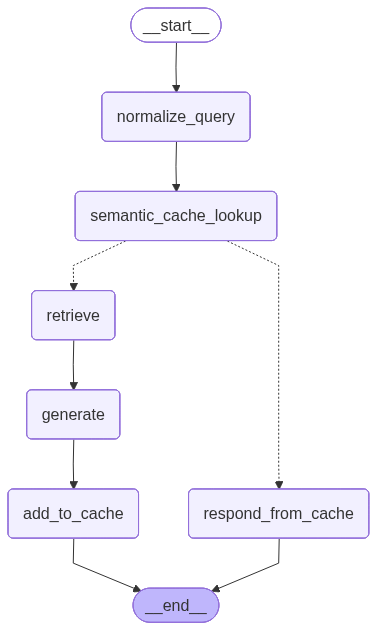

In [14]:
# ------------------------------------------------------------
# 6. State Graph
# ------------------------------------------------------------

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

graph = StateGraph(RAGState)

graph.add_node(normalize_query)
graph.add_node(semantic_cache_lookup)
graph.add_node(respond_from_cache)
graph.add_node(retrieve)
graph.add_node(generate)
graph.add_node(add_to_cache)

graph.set_entry_point('normalize_query')
graph.add_edge('normalize_query', 'semantic_cache_lookup')

def _branch(state: RAGState) -> RAGState:
    return 'respond_from_cache' if state.get('cache_hit') else 'retrieve'

graph.add_conditional_edges(
    'semantic_cache_lookup',
    _branch,
    {
        'respond_from_cache': 'respond_from_cache',
        'retrieve': 'retrieve'
    }
)
graph.add_edge('respond_from_cache', END)
graph.add_edge('retrieve', 'generate')
graph.add_edge('generate', 'add_to_cache')
graph.add_edge('add_to_cache', END)

memory = MemorySaver()
builder = graph.compile(checkpointer=memory)
builder

In [10]:
# ------------------------------------------------------------
# 7. Answer
# ------------------------------------------------------------

thread_config = {'configurable': {'thread_id': 'aaron_1'}}

question_1 = 'What is LangGraph?'
output_1 = builder.invoke({'question': question_1, 'context_docs': [], 'citations': []}, thread_config)

print('✅ Answer: ', output_1['answer'])
print('📝 Citations: ', output_1.get('citations'))
print('📊 Cache Hit?: ', output_1.get('cache_hit'))

✅ Answer:  LangGraph is a framework that lets you compose stateful large‑language‑model (LLM) workflows as a graph structure, enabling modular, controllable pipelines for LLM‑driven applications【doc-1】.
📝 Citations:  ['[doc-1]', '[doc-2]', '[doc-3]', '[doc-4]']
📊 Cache Hit?:  False


In [15]:
question_2 = 'Can you explain the LangGraph?'
output_2 = builder.invoke({'question': question_2, 'context_docs': [], 'citations': []}, thread_config)

print('✅ Answer: ', output_2['answer'])
print('📝 Citations: ', output_2.get('citations'))
print('📊 Cache Hit?: ', output_2.get('cache_hit'))

✅ Answer:  LangGraph is a framework that lets you compose stateful large‑language‑model (LLM) workflows as a graph structure, enabling modular, controllable pipelines for LLM‑driven applications【doc-1】.
📝 Citations:  ['(cache)']
📊 Cache Hit?:  True
